# Supervised Learning Capstone: Diabetes Progression Regression

            ## 1. Learning objectives

            - Frame an end-to-end regression problem
- Audit, engineer, baseline, compare, and tune models
- Perform held-out evaluation and residual error analysis

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Predict the one-year disease-progression measure in the scikit-learn Diabetes benchmark. Success is lower RMSE than a mean baseline, with MAE and R² as guardrails.

            ## 4. Real-world use cases

            - Educational clinical-risk regression
- Tabular model comparison
- Residual-based error analysis

            ## 5. Core intuition in simple language

            A useful capstone earns complexity: begin with the mean, add an interpretable linear model, compare ensembles, tune without seeing test outcomes, and document limitations.

## 6. Mathematical foundation

            $$RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2},\qquad R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.$$

            **Every symbol:**

            - $n$ is evaluated row count.
- $y_i$ is true progression.
- $\hat y_i$ is prediction.
- $\bar y$ is mean target.
- $RMSE$ is error in target units.
- $R^2$ compares with the mean baseline.

            **Why the equation is needed:** RMSE defines primary success and emphasizes large misses; R² shows improvement relative to a constant prediction.

            **Small numerical example:** For errors [1,-2], RMSE=sqrt((1+4)/2)=1.581.

            **Connection to Python:** mean_squared_error(y, prediction)**.5 and r2_score(y, prediction) implement the metrics.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

The mean regressor is implemented directly and establishes the minimum useful benchmark.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class MeanRegressor:
    def fit(self,target):
        self.mean_=float(np.mean(target)); return self
    def predict(self,size):
        return np.full(size,self.mean_)

print("Mean-baseline example:",MeanRegressor().fit([2,4,6]).predict(3))

Mean-baseline example: [4. 4. 4.]


## 10. Implementation using a standard library

Ridge, Random Forest, and Gradient Boosting represent linear, bagged-tree, and sequential-tree families.

## 11. Dataset loading and exploration

The bundled dataset has 442 observations, ten standardized baseline variables, and a numeric progression target.

## 12. Data preprocessing

A BMI-by-blood-pressure interaction is engineered before splitting columns; fitted scaling remains inside the Ridge pipeline.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Dataset: (442, 11) missing: 0 duplicates: 0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0


,model,MAE,RMSE,R2
1,Ridge,42.362,51.411,0.518
3,Gradient boosting,43.534,53.622,0.475
2,Random forest,43.752,54.188,0.464
0,Mean baseline,64.129,75.639,-0.044


Selected: Ridge held-out MAE/RMSE/R2: 41.98 52.36 0.483


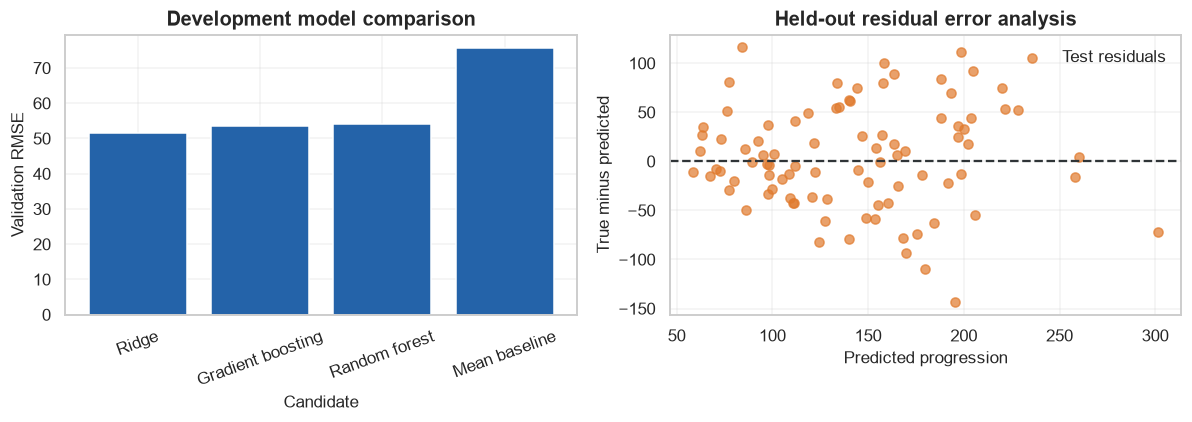

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

data=load_diabetes(as_frame=True)
frame=data.frame.copy()
print("Dataset:",frame.shape,"missing:",int(frame.isna().sum().sum()),"duplicates:",int(frame.duplicated().sum()))
display(frame.head(3))
features=data.data.copy()
features["bmi_bp_interaction"]=features["bmi"]*features["bp"]
X_development,X_test,y_development,y_test=train_test_split(features,data.target,test_size=.2,random_state=RANDOM_SEED)
X_train,X_validation,y_train,y_validation=train_test_split(X_development,y_development,test_size=.25,random_state=RANDOM_SEED)
models={
    "Ridge":make_pipeline(StandardScaler(),Ridge(alpha=10)),
    "Random forest":RandomForestRegressor(n_estimators=180,max_depth=5,random_state=RANDOM_SEED),
    "Gradient boosting":GradientBoostingRegressor(n_estimators=100,max_depth=2,learning_rate=.05,random_state=RANDOM_SEED),
}
rows=[{"model":"Mean baseline","MAE":mean_absolute_error(y_validation,np.full(len(y_validation),y_train.mean())),"RMSE":mean_squared_error(y_validation,np.full(len(y_validation),y_train.mean()))**.5,"R2":r2_score(y_validation,np.full(len(y_validation),y_train.mean()))}]
for name,model in models.items():
    model.fit(X_train,y_train); prediction=model.predict(X_validation)
    rows.append({"model":name,"MAE":mean_absolute_error(y_validation,prediction),"RMSE":mean_squared_error(y_validation,prediction)**.5,"R2":r2_score(y_validation,prediction)})
comparison=pd.DataFrame(rows).sort_values("RMSE"); display(comparison.round(3))
best_name=comparison.iloc[0]["model"]; best_model=models[best_name]; best_model.fit(X_development,y_development); test_prediction=best_model.predict(X_test)
print("Selected:",best_name,"held-out MAE/RMSE/R2:",round(mean_absolute_error(y_test,test_prediction),2),round(mean_squared_error(y_test,test_prediction)**.5,2),round(r2_score(y_test,test_prediction),3))
residuals=y_test-test_prediction
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].bar(comparison["model"],comparison["RMSE"],color=COURSE_COLORS["blue"]); axes[0].set(title="Development model comparison",xlabel="Candidate",ylabel="Validation RMSE"); axes[0].tick_params(axis="x",rotation=20)
axes[1].scatter(test_prediction,residuals,color=COURSE_COLORS["orange"],alpha=.7,label="Test residuals"); axes[1].axhline(0,color=COURSE_COLORS["charcoal"],linestyle="--"); axes[1].set(title="Held-out residual error analysis",xlabel="Predicted progression",ylabel="True minus predicted"); axes[1].legend()
figure.tight_layout(); plt.show()

**How to interpret the result:** The comparison tests whether nonlinear ensembles beat the baseline; residuals expose target ranges where systematic under- or overprediction remains.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Gradient-boosting depth and stage count are compared only on validation RMSE. The test set is reserved for the frozen winner.

,depth,estimators,validation_RMSE
0,1,50,55.64
1,1,100,54.05
2,1,180,53.48
3,2,50,54.01
4,2,100,53.62
5,2,180,53.49
6,3,50,55.67
7,3,100,55.69
8,3,180,57.23


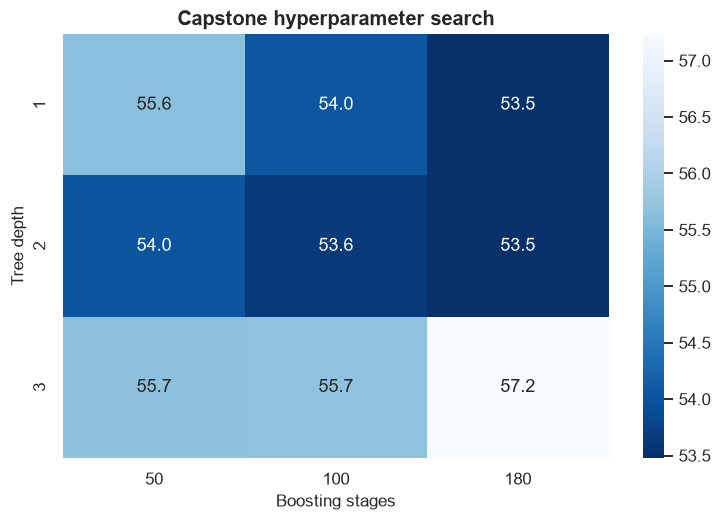

In [4]:
rows=[]
for depth in [1,2,3]:
    for estimators in [50,100,180]:
        candidate=GradientBoostingRegressor(max_depth=depth,n_estimators=estimators,learning_rate=.05,random_state=RANDOM_SEED).fit(X_train,y_train)
        rows.append({"depth":depth,"estimators":estimators,"validation_RMSE":mean_squared_error(y_validation,candidate.predict(X_validation))**.5})
tuning=pd.DataFrame(rows); display(tuning.round(2))
pivot=tuning.pivot(index="depth",columns="estimators",values="validation_RMSE")
figure,axis=plt.subplots(); sns.heatmap(pivot,annot=True,fmt=".1f",cmap="Blues_r",ax=axis); axis.set(title="Capstone hyperparameter search",xlabel="Boosting stages",ylabel="Tree depth"); plt.show()

## 18. Common mistakes

            - Treating the benchmark as deployment-ready medicine
- Tuning on test RMSE
- Ignoring target-range error patterns
- Claiming the engineered interaction is causal

            ## 19. Advantages and disadvantages

            **Advantages**

            - Complete offline workflow
- Multiple model families and explicit baseline
- Held-out residual analysis

            **Disadvantages**

            - Small benchmark sample
- No temporal or external validation
- No uncertainty intervals or clinical utility analysis

            ## 20. When to use and when not to use the algorithm

            **Use it when:** learning reproducible supervised workflows or benchmarking methods on small continuous-target data.

            **Do not use it when:** making clinical decisions without prospective validation, governance, calibration, uncertainty, and subgroup analysis.

## 21. Exercises

1. **Conceptual:** Why use both RMSE and MAE?
2. **Mathematical/hand calculation:** For true [2,4] and predicted [1,7], compute RMSE.
3. **Coding/experimentation:** Repeat the comparison across five splits and report mean plus standard deviation.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. RMSE emphasizes large errors while MAE expresses a robust typical absolute miss; disagreement is diagnostically useful.
2. Errors [1,-3] give squared errors [1,9], MSE=5, RMSE=sqrt(5)=2.236.
3. Loop over fixed seeds, repeat every split and fitted preprocessing step, retain every score, and summarize variability without selecting the best split.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - Business framing and success metrics precede model choice
- Feature engineering and preprocessing must respect split boundaries
- Baselines make added complexity accountable
- Final evaluation, residual analysis, limitations, and improvements form one conclusion

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)